# **midterm eda process — spring 2026**

**dataset:** `Quality_of_Life.csv`  

### **imports & data loading**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Quality_of_Life.csv')

## **inspect the data**

In [32]:
df.shape

(236, 19)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          190 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    234 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               221 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   114 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            191 non-null    object 
 11  Property Price to Income Value     236 non-null    object 

In [34]:
df.describe()

,Purchasing Power Value,Safety Value,Health Care Value,Climate Value,Cost of Living Value,Traffic Commute Time Value,Pollution Value
count,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000,236.000000
mean,55.573305,55.274449,54.731568,37.598178,37.526314,28.492966,54.266186
std,52.008245,16.914298,20.607381,40.851542,26.026565,17.347242,25.853695
min,0.000000,0.000000,0.000000,-3.540000,0.000000,0.000000,0.000000
25%,16.340000,43.857500,45.807500,0.000000,24.550000,17.100000,35.700000
50%,42.930000,54.635000,57.150000,0.000000,36.895000,29.845000,59.765000
75%,85.940000,68.132500,68.447500,79.332500,51.090000,38.870000,73.740000
max,281.830000,100.000000,100.000000,99.890000,137.370000,100.000000,106.900000


In [35]:
df.head()

,country,Purchasing Power Value,Purchasing Power Category,Safety Value,Safety Category,Health Care Value,Health Care Category,Climate Value,Climate Category,Cost of Living Value,Cost of Living Category,Property Price to Income Value,Property Price to Income Category,Traffic Commute Time Value,Traffic Commute Time Category,Pollution Value,Pollution Category,Quality of Life Value,Quality of Life Category
0,Afghanistan,32.15,'Very Low',25.33,'Low',24.24,'Low',0.00,NaN,21.08,'Very Low',7.8,'Low',56.17,'Very High',84.44,'Very High',0.0,NaN
1,Aland Islands,125.01,'Very High',71.81,'High',79.72,'High',0.00,NaN,53.44,'Low',5.33,'Low',19.05,'Very Low',18.05,'Very Low',0.0,NaN
2,Albania,42.82,'Low',55.52,'Moderate',48.21,'Moderate',86.43,'Very High',40.85,'Low',14.88,'High',36.74,'Moderate',77.25,'High',': 104.16','Low'
3,Alderney,0.00,NaN,83.79,'Very High',100.00,'Very High',0.00,NaN,0.00,NaN,0.0,NaN,5.00,'Very Low',1.72,'Very Low',0.0,NaN
4,Algeria,27.60,'Very Low',47.54,'Moderate',54.43,'Moderate',94.82,'Very High',25.31,'Very Low',21.7,'Very High',45.09,'High',63.87,'High',': 98.83','Very Low'


**`initial data review`**

* this dataset has multiple rows and columns representing different quality of life metrics across regions. i used .info() and .describe() to observe the data types, missing values, and summary statistics like the mean and standard deviation. some columns that should be numeric appear as object types, indicating the need for data cleaning.

## **check missing values**

In [36]:
df.isna().sum()

country                                0
Purchasing Power Value                 0
Purchasing Power Category             46
Safety Value                           0
Safety Category                        2
Health Care Value                      0
Health Care Category                  15
Climate Value                          0
Climate Category                     122
Cost of Living Value                   0
Cost of Living Category               45
Property Price to Income Value         0
Property Price to Income Category     21
Traffic Commute Time Value             0
Traffic Commute Time Category         29
Pollution Value                        0
Pollution Category                    10
Quality of Life Value                  0
Quality of Life Category             122
dtype: int64

## **clean numeric columns**

In [37]:
df["Property Price to Income Value"] = pd.to_numeric(
    df["Property Price to Income Value"],
    errors="coerce"
)

df["Quality of Life Value"] = (
    df["Quality of Life Value"]
    .astype(str)
    .str.replace("': ", "", regex=False)
    .str.replace("'", "", regex=False)
)

df["Quality of Life Value"] = pd.to_numeric(
    df["Quality of Life Value"],
    errors="coerce"
)

## **clean category columns**

In [38]:
category_cols = [col for col in df.columns if "Category" in col]

for col in category_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("'", "", regex=False)
        .replace("nan", pd.NA)
    )

## **reinspect after cleaning**

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            236 non-null    object 
 1   Purchasing Power Value             236 non-null    float64
 2   Purchasing Power Category          190 non-null    object 
 3   Safety Value                       236 non-null    float64
 4   Safety Category                    234 non-null    object 
 5   Health Care Value                  236 non-null    float64
 6   Health Care Category               221 non-null    object 
 7   Climate Value                      236 non-null    float64
 8   Climate Category                   114 non-null    object 
 9   Cost of Living Value               236 non-null    float64
 10  Cost of Living Category            191 non-null    object 
 11  Property Price to Income Value     233 non-null    float64

In [40]:
df.describe()

,Purchasing Power Value,Safety Value,Health Care Value,Climate Value,Cost of Living Value,Property Price to Income Value,Traffic Commute Time Value,Pollution Value,Quality of Life Value
count,236.000000,236.000000,236.000000,236.000000,236.000000,233.000000,236.000000,236.000000,236.000000
mean,55.573305,55.274449,54.731568,37.598178,37.526314,22.297210,28.492966,54.266186,63.466780
std,52.008245,16.914298,20.607381,40.851542,26.026565,52.251007,17.347242,25.853695,73.307577
min,0.000000,0.000000,0.000000,-3.540000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.340000,43.857500,45.807500,0.000000,24.550000,6.390000,17.100000,35.700000,0.000000
50%,42.930000,54.635000,57.150000,0.000000,36.895000,11.610000,29.845000,59.765000,0.000000
75%,85.940000,68.132500,68.447500,79.332500,51.090000,17.490000,38.870000,73.740000,127.135000
max,281.830000,100.000000,100.000000,99.890000,137.370000,450.400000,100.000000,106.900000,224.310000


In [41]:
df.isna().sum()

country                                0
Purchasing Power Value                 0
Purchasing Power Category             46
Safety Value                           0
Safety Category                        2
Health Care Value                      0
Health Care Category                  15
Climate Value                          0
Climate Category                     122
Cost of Living Value                   0
Cost of Living Category               45
Property Price to Income Value         3
Property Price to Income Category     21
Traffic Commute Time Value             0
Traffic Commute Time Category         29
Pollution Value                        0
Pollution Category                    10
Quality of Life Value                  0
Quality of Life Category             122
dtype: int64

**`data cleaning`**
* the two columns: Property Price to Income Value & Quality of Life Value should be numeric, and was converted using pd.to_numeric(), any invalid values were coerced into NaN. i also removed extra quotation marks from category columns to standardize formatting, overall ensuring the dataset was properly structured for analysis and visualization.

## **plot 1 - seaborn histogram**

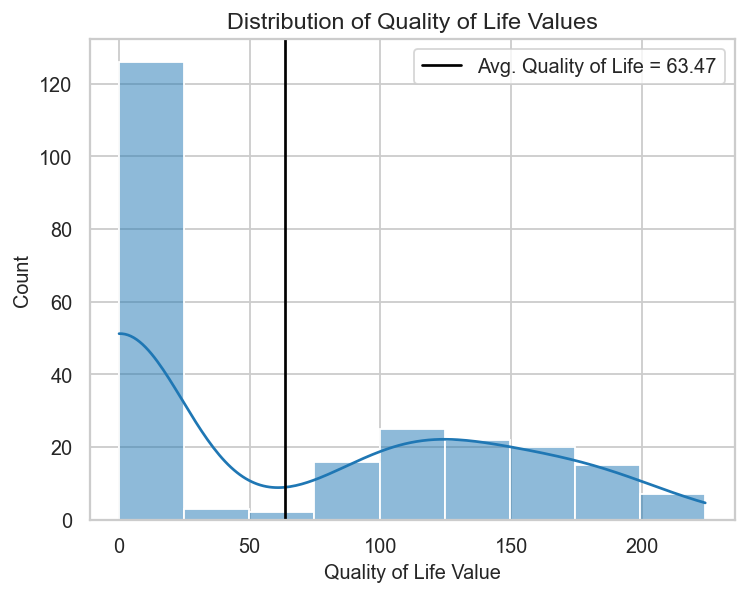

In [42]:
sns.set_palette("tab10")

fig, ax = plt.subplots()

ax = sns.histplot(data=df, x="Quality of Life Value", kde=True)

mean_qol = df["Quality of Life Value"].mean()
ax.axvline(mean_qol, color="black", label=f"Avg. Quality of Life = {mean_qol:.2f}")

ax.set_title("Distribution of Quality of Life Values")
ax.set_xlabel("Quality of Life Value")
ax.set_ylabel("Count")

plt.legend()
plt.show()

**`findings (plot 1)`**

  * the histogram shows how quality of life values are distributed across the dataset. most values look clustered within a certain range, with less observations at the higher end, showing a slight right skew. the mean line shows the average value and helps compare how the data is distributed relative to the center.

## **plot 2 - matplotlib scatter plot**

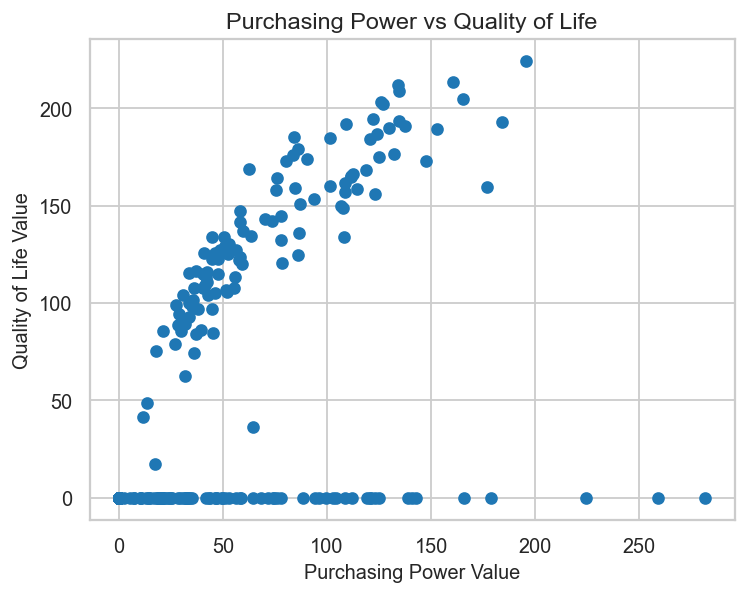

In [43]:
fig, ax = plt.subplots()

ax.scatter(df["Purchasing Power Value"], df["Quality of Life Value"])

ax.set_title("Purchasing Power vs Quality of Life")
ax.set_xlabel("Purchasing Power Value")
ax.set_ylabel("Quality of Life Value")

plt.show()

**`findings (plot 2)`**

  * the scatter plot shows the relationship between purchasing power and quality of life. we see a general positive trend, meaning that higher purchasing power can often be associated with higher quality of life.

## **plot 3 - seaborn box plot**

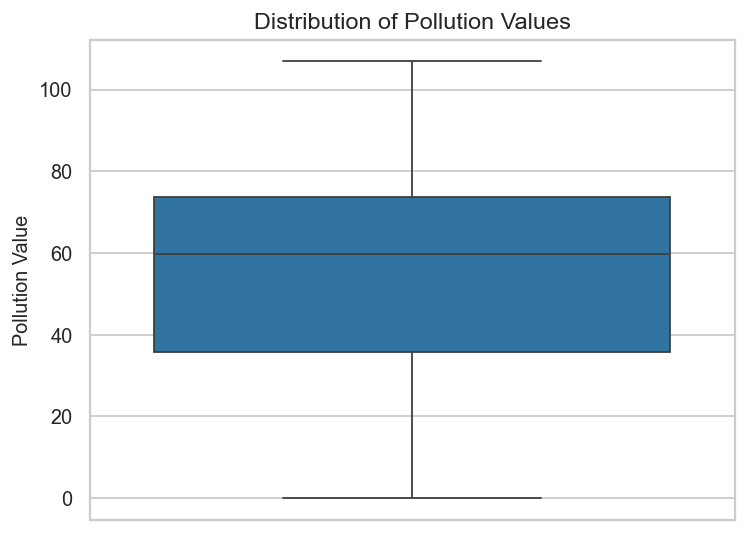

In [44]:
sns.set_palette("tab10")

fig, ax = plt.subplots()

ax = sns.boxplot(y="Pollution Value", data=df)

ax.set_title("Distribution of Pollution Values")
ax.set_ylabel("Pollution Value")

plt.show()

**`findings (plot 3)`**

  * the box plot shows the distribution of pollution values, including the median and interquartile range. most values fall within a moderate range, but there are some higher values that may be considered outliers. this shows that variability in pollution levels across different regions.

## **plot 4 - seaborn bar plot**

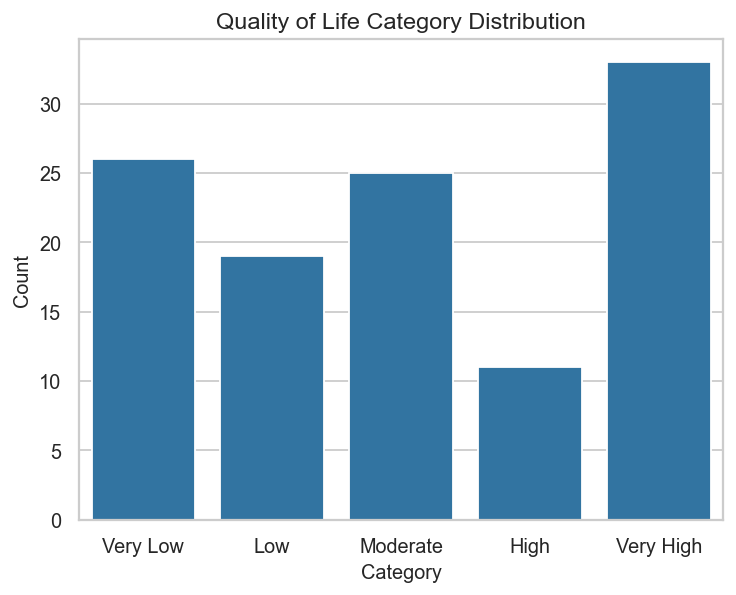

In [45]:
category_counts = (
    df["Quality of Life Category"]
    .value_counts()
    .reindex(["Very Low", "Low", "Moderate", "High", "Very High"])
)

fig, ax = plt.subplots()

sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)

ax.set_title("Quality of Life Category Distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Count")

plt.show()

* **`findings (plot 4)`**
  
  * the bar plot shows how many regions fall into each quality of life category. it provides a clear comparison of category frequencies and helps identify whether most regions fall into lower, moderate, or higher quality-of-life groups. this complements the histogram by grouping values into meaningful categories.

# **final summary**

* this EDA followed a structured approach similar to the case study by first inspecting the dataset using .info(), .describe(), and .head(). the data required some cleaning to convert certain columns into numeric format and standardize text formatting. three main visualizations were created: a histogram to examine distribution, a scatter plot to explore relationships, and a box plot to analyze spread and outliers. these visualizations provided insight into the dataset and highlighted relationships between key variables.